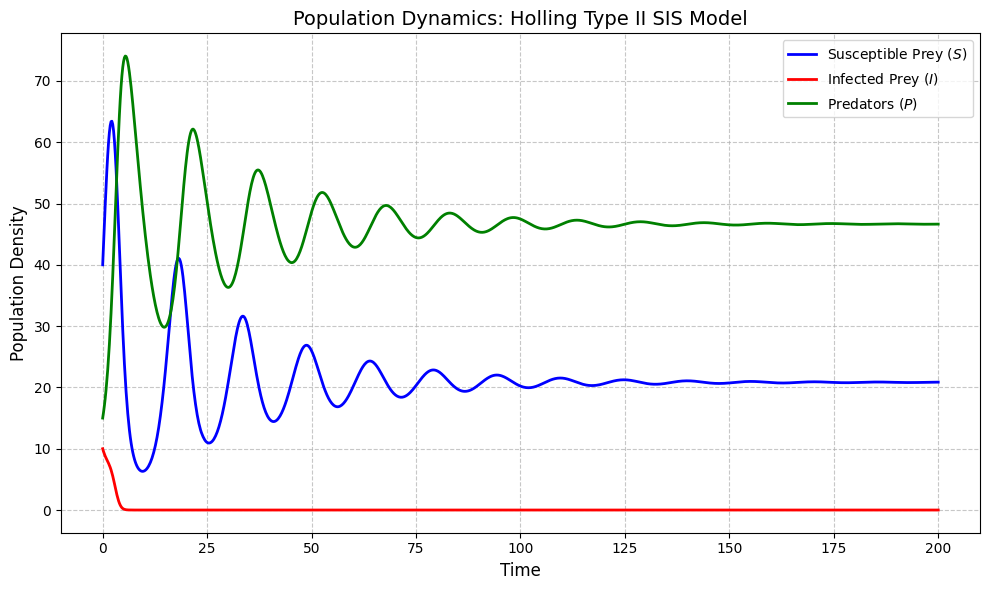

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def holling_type2_sis_model(t, y, r, K, beta, rho, alpha1, alpha2, h1, h2, delta, mu, e, gamma):
    S, I, P = y
    
    D = 1 + alpha1 * h1 * S + alpha2 * h2 * I
    
    dSdt = r * S * (1 - (S + I) / K) - beta * S * I + rho * I - (alpha1 * S * P) / D
    
    dIdt = beta * S * I - (delta + mu + rho) * I - (alpha2 * I * P) / D
    
    dPdt = P * ((e * (alpha1 * S + alpha2 * I)) / D - gamma)
    
    return [dSdt, dIdt, dPdt]

params = {
    'r': 1.0,        # Intrinsic growth rate of prey
    'K': 200.0,      # Carrying capacity
    'beta': 0.015,    # Disease transmission rate
    'rho': 0.3,     # Recovery rate (I -> S)
    'alpha1': 0.02,   # Attack rate on susceptible prey
    'alpha2': 0.03,  # Attack rate on infected prey (often easier to catch)
    'h1': 0.1,       # Handling time for susceptible prey
    'h2': 0.15,      # Handling time for infected prey
    'delta': 0.1,    # Disease-induced mortality
    'mu': 0.05,      # Natural mortality of prey
    'e': 0.5,        # Predator conversion efficiency
    'gamma': 0.2     # Predator mortality rate
}

y0 = [40.0, 10.0, 15.0] 
t_span = (0, 200)       
t_eval = np.linspace(t_span[0], t_span[1], 1000)

sol = solve_ivp(
    holling_type2_sis_model, 
    t_span, 
    y0, 
    args=tuple(params.values()), 
    t_eval=t_eval,
    method='RK45'
)

plt.figure(figsize=(10, 6))

plt.plot(sol.t, sol.y[0], label='Susceptible Prey ($S$)', color='blue', linewidth=2)
plt.plot(sol.t, sol.y[1], label='Infected Prey ($I$)', color='red', linewidth=2)
plt.plot(sol.t, sol.y[2], label='Predators ($P$)', color='green', linewidth=2)

plt.title('Population Dynamics: Holling Type II SIS Model', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Population Density', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()